<a href="https://colab.research.google.com/github/maukate895-sketch/Examen_Primer_Parcial_INF672_Arce/blob/main/Examen_Primer_Parcial_INF672_Arce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## EJERCICIO 1 — Probabilidad por Conteo y Simulación

import itertools
import numpy as np
import pandas as pd

# 1. Valor exacto por conteo
pares = list(itertools.product(range(1, 7), repeat=2))
favorables = [par for par in pares if 6 in par]
valor_exacto = len(favorables) / len(pares)

print(f"Pares posibles: {len(pares)}")
print(f"Pares favorables: {len(favorables)}")
print(f"Valor exacto: {valor_exacto:.6f}")

# 2 y 3. Estimación por simulación Monte Carlo
rng = np.random.default_rng(42)

resultados = []
for N in [100, 1_000, 100_000]:
    tiradas = rng.integers(1, 7, size=(N, 2))
    tiene_seis = np.any(tiradas == 6, axis=1)
    estimacion = tiene_seis.mean()
    error = abs(estimacion - valor_exacto)
    resultados.append([N, estimacion, error])

tabla_e1 = pd.DataFrame(resultados, columns=["N", "Estimación", "Error absoluto"])
print("\nResultados de la simulación:")
display(tabla_e1)

Pares posibles: 36
Pares favorables: 11
Valor exacto: 0.305556

Resultados de la simulación:


,N,Estimación,Error absoluto
0,100,0.24000,0.065556
1,1000,0.31000,0.004444
2,100000,0.30583,0.000274


**Pares favorables:**
$11/36 \approx 0.305556$ ($30.56\%$)

**¿Cuál se acercó más y por qué?**
La simulación con $N = 100\,000$ (con un error de apenas $0.000274$), debido a la Ley de los Grandes Números: a mayor número de repeticiones, la frecuencia observada converge al valor de probabilidad teórico

**¿Qué pasa con pocas tiradas?**
Con $N = 100$, el azar produce una alta variabilidad (error de $0.065556$), lo que demuestra que pocas muestras no representan fielmente la distribución real.

In [3]:
# EJERCICIO 2: Perfil Estadístico e Imputación de Datos (Conjunto Iris)
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

# Cargar dataset Iris
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="target")
caracteristicas = list(df.columns[:-1])

# 1. Perfil estadístico por especie
filas = []
for especie, grupo in df.groupby("species"):
    for col in caracteristicas:
        s = grupo[col]
        filas.append({
            "Especie": especie,
            "Característica": col,
            "Media": s.mean(),
            "Mediana": s.median(),
            "Desv. Std": s.std(),
            "Q1": s.quantile(0.25),
            "Q2": s.quantile(0.50),
            "Q3": s.quantile(0.75)
        })

tabla_e2 = pd.DataFrame(filas)
print("Perfil Estadístico por Especie:")
display(tabla_e2.round(3))

# 2. Rellenar faltantes con la mediana por especie
df_limpio = df.copy()
rng_nan = np.random.default_rng(42)

for col in caracteristicas:
    pos = rng_nan.choice(df_limpio.index, size=2, replace=False)
    df_limpio.loc[pos, col] = np.nan

for col in caracteristicas:
    df_limpio[col] = df_limpio.groupby("species")[col].transform(
        lambda s: s.fillna(s.median())
    )

print("\nValores nulos después de imputar:", df_limpio[caracteristicas].isna().sum().sum())

Perfil Estadístico por Especie:


,Especie,Característica,Media,Mediana,Desv. Std,Q1,Q2,Q3
0,setosa,sepal length (cm),5.006,5.00,0.352,4.800,5.00,5.200
1,setosa,sepal width (cm),3.428,3.40,0.379,3.200,3.40,3.675
2,setosa,petal length (cm),1.462,1.50,0.174,1.400,1.50,1.575
3,setosa,petal width (cm),0.246,0.20,0.105,0.200,0.20,0.300
4,versicolor,sepal length (cm),5.936,5.90,0.516,5.600,5.90,6.300
5,versicolor,sepal width (cm),2.770,2.80,0.314,2.525,2.80,3.000
6,versicolor,petal length (cm),4.260,4.35,0.470,4.000,4.35,4.600
7,versicolor,petal width (cm),1.326,1.30,0.198,1.200,1.30,1.500
8,virginica,sepal length (cm),6.588,6.50,0.636,6.225,6.50,6.900
9,virginica,sepal width (cm),2.974,3.00,0.322,2.800,3.00,3.175



Valores nulos después de imputar: 0


**¿Por qué se prefiere la mediana sobre la media para imputar?**

La mediana es una medida de tendencia central robusta e insensible a valores atípicos (outliers) o distribuciones sesgadas. Además, al calcular la mediana por especie, mantenemos la coherencia física real de cada categoría de flor.

**¿Qué variable permite separar mejor las especies?**
petal length (cm) (Largo del pétalo). Sus medias difieren significativamente entre especies: 1.462 (setosa), 4.260 (versicolor) y 5.552 (virginica), mostrando grupos claramente separables.

**¿Qué variable las confunde más?**

sepal width (cm) (Ancho del sépalo). Sus valores promedio son muy similares entre sí (3.428, 2.770 y 2.974), generando solapamiento entre especies.

In [4]:
# EJERCICIO 3: Métricas de Similitud Programadas desde Cero
# 1. Funciones manuales con numpy
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def producto_punto(a, b):
    return np.sum(a * b)

def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 2. Comparación de pares de flores
X = iris.data.to_numpy()
y = iris.target.to_numpy()

pares = [(0, 1), (0, 50), (1, 100), (50, 100)]
res_pares = []

for i, j in pares:
    res_pares.append({
        "Par": f"{i} - {j}",
        "Especies": f"{iris.target_names[y[i]]} vs {iris.target_names[y[j]]}",
        "Dist. Euclidiana": distancia_euclidiana(X[i], X[j]),
        "Producto Punto": producto_punto(X[i], X[j]),
        "Similitud Coseno": similitud_coseno(X[i], X[j])
    })

tabla_e3 = pd.DataFrame(res_pares)
display(tabla_e3.round(4))

,Par,Especies,Dist. Euclidiana,Producto Punto,Similitud Coseno
0,0 - 1,setosa vs setosa,0.5385,37.49,0.9986
1,0 - 50,setosa vs versicolor,4.0037,53.76,0.9284
2,1 - 100,setosa vs virginica,5.3385,49.67,0.8713
3,50 - 100,versicolor vs virginica,1.8439,86.36,0.9821



 **¿Las flores de la misma especie salieron más parecidas?**

Sí, el par $0 - 1$ (ambas de la especie *setosa*) dio la menor distancia euclidiana ($0.5385$) y la mayor similitud coseno ($0.9986$).

 **¿Las métricas ordenan de la misma forma?**

No necesariamente, ya que la distancia euclidiana mide la diferencia física absoluta en magnitud, mientras que la similitud coseno evalúa únicamente el ángulo u orientación geométrica entre los vectores de características.

Resultados finales del Descenso de Gradiente:


,Tasa (alpha),x final (paso 20),Error |x - 4|
0,0.01,8.005648,4.005648
1,0.10,4.069175,0.069175
2,1.10,234.025600,230.025600


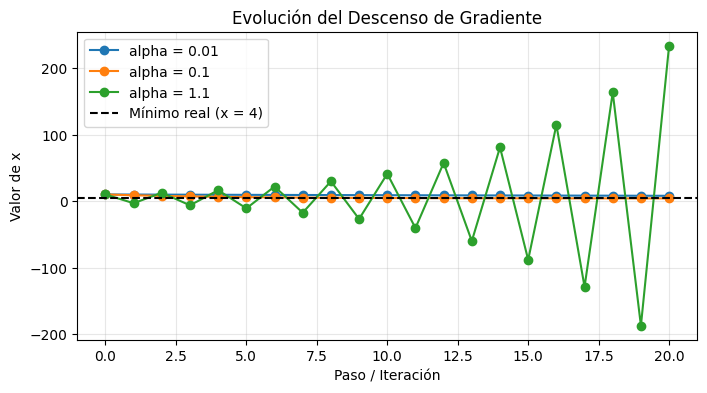

In [5]:
# EJERCICIO 4: Descenso de Gradiente Univariado
import matplotlib.pyplot as plt

def descenso_gradiente(tasa, pasos=20, x_inicial=10):
    x = x_inicial
    trayectoria = [x]
    for _ in range(pasos):
        derivada = 2 * (x - 4)  # Derivada f'(x)
        x = x - tasa * derivada
        trayectoria.append(x)
    return trayectoria

tasas = [0.01, 0.1, 1.1]
trayectorias = {t: descenso_gradiente(t) for t in tasas}

# Tabla comparativa final
tabla_e4 = pd.DataFrame({
    "Tasa (alpha)": tasas,
    "x final (paso 20)": [trayectorias[t][-1] for t in tasas],
    "Error |x - 4|": [abs(trayectorias[t][-1] - 4) for t in tasas]
})
print("Resultados finales del Descenso de Gradiente:")
display(tabla_e4.round(6))

# Gráfica
plt.figure(figsize=(8, 4))
for t in tasas:
    plt.plot(range(len(trayectorias[t])), trayectorias[t], marker="o", label=f"alpha = {t}")

plt.axhline(4, color="black", linestyle="--", label="Mínimo real (x = 4)")
plt.xlabel("Paso / Iteración")
plt.ylabel("Valor de x")
plt.title("Evolución del Descenso de Gradiente")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* **$\alpha = 0.01$ **texto en negrita** (Tasa muy pequeña):** Convergencia muy lenta. En 20 iteraciones solo llegó a $x = 8.0056$ (error de $4.0056$), requiriendo más pasos para alcanzar el mínimo real ($x = 4$).

* **$\alpha = 0.1$ (Tasa adecuada):** Convergencia rápida y estable. Alcanzó $x = 4.0691$ con un error mínimo de $0.0691$ en solo 20 iteraciones.

* **$\alpha = 1.1$ (Tasa excesiva):** Divergencia. Produce oscilaciones cada vez más grandes, alejándose del mínimo hasta alcanzar $x = 234.0256$ (error de $230.0256$).